In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import faiss
import torch

from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns


Mounted at /content/drive


In [3]:
BASE_PATH = "/content/drive/MyDrive/VTPNLP10/new_dataset_split/"

train_df = pd.read_csv(BASE_PATH + "train.csv")
val_df   = pd.read_csv(BASE_PATH + "validation.csv")
test_df  = pd.read_csv(BASE_PATH + "test.csv")

print(train_df.shape, val_df.shape, test_df.shape)

(112819, 2) (14102, 2) (14103, 2)


In [4]:
def clean_df(df):
    df = df.copy()
    df["questions"] = df["questions"].astype(str).str.lower().str.strip()
    df["answers"]   = df["answers"].astype(str).str.lower().str.strip()
    df = df.drop_duplicates()
    df = df.dropna()
    return df.reset_index(drop=True)

train_df = clean_df(train_df)
val_df   = clean_df(val_df)
test_df  = clean_df(test_df)

print(train_df.shape, val_df.shape, test_df.shape)

(112423, 2) (14096, 2) (14100, 2)


In [5]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embedder = SentenceTransformer(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
train_questions = train_df["questions"].tolist()
train_answers   = train_df["answers"].tolist()

train_embeddings = embedder.encode(
    train_questions,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(train_embeddings.shape)

Batches:   0%|          | 0/3514 [00:00<?, ?it/s]

(112423, 384)


In [7]:
dimension = train_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)   # cosine similarity
index.add(train_embeddings)

print("FAISS index size:", index.ntotal)

FAISS index size: 112423


In [8]:
SAVE_PATH = "/content/drive/MyDrive/VTPNLP10/retrieval_model/"

embedder.save(SAVE_PATH + "sentence_model")
faiss.write_index(index, SAVE_PATH + "faiss.index")

train_df.to_csv(SAVE_PATH + "train_data.csv", index=False)

print("Model & index saved successfully")

Model & index saved successfully


In [9]:
def retrieve_answer(question, k=1):
    query_embedding = embedder.encode(
        [question.lower()],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = index.search(query_embedding, k)
    idx = indices[0][0]

    return train_questions[idx], train_answers[idx], scores[0][0]

In [10]:
samples = test_df.sample(5, random_state=42)

for i, row in enumerate(samples.itertuples(), 1):
    q = row.questions
    gt = row.answers

    rq, pred, score = retrieve_answer(q)

    print(f"\n🔹 SAMPLE {i}")
    print("Question:", q)
    print("Ground Truth:", gt)
    print("Retrieved Q:", rq)
    print("Predicted Answer:", pred)
    print("Similarity Score:", round(score, 3))


🔹 SAMPLE 1
Question: query regarding antracnose of chilly
Ground Truth: advised to spray blitox @ 2gm/lit
Retrieved Q: query regarding antracnose of chilly
Predicted Answer: advised to apply blitox 50wp @ 2gm/lit and amister @ 2ml/lit
Similarity Score: 1.0

🔹 SAMPLE 2
Question: query regarding management of nutrient in cucumber.
Ground Truth: advise to apply urea:sssp:mop @ 15:25:12 kg/bigha.
Retrieved Q: query regarding nutrient management in cucumber
Predicted Answer: application of urea-7 kg,mop- 9 kg as top dressed to be done at 30 days after emergence.spraying of npk 19:19:19 @ 10 g/l of water for two times at an interval of 15 days
Similarity Score: 0.974

🔹 SAMPLE 3
Question: asking about the control measure for bud rot in coconut
Ground Truth: recommended to apply bordeaux mixture(add 100 gram copper sulphate in 5 lit water in a container,100 gram lime in 5 lit water,mix it in 3 rd container for 10 lit solution)
Retrieved Q: asking about the control measure for bud rot in coco

In [11]:
def evaluate_accuracy(df, threshold=0.75):
    y_true = []
    y_pred = []

    for row in df.itertuples():
        _, _, score = retrieve_answer(row.questions)
        y_true.append(1)
        y_pred.append(1 if score >= threshold else 0)

    return accuracy_score(y_true, y_pred)

In [12]:
train_acc = evaluate_accuracy(train_df.sample(1000, random_state=42))
test_acc  = evaluate_accuracy(test_df.sample(1000, random_state=42))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 1.0
Test Accuracy : 0.959


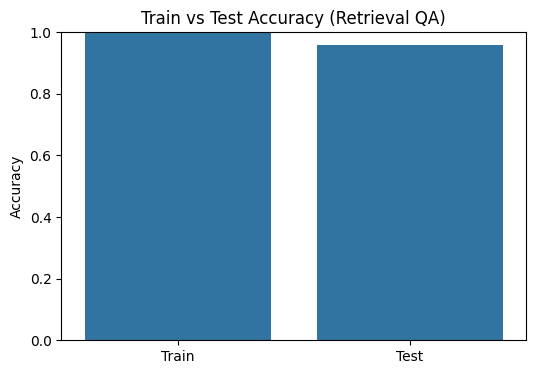

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x=["Train", "Test"], y=[train_acc, test_acc])
plt.title("Train vs Test Accuracy (Retrieval QA)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

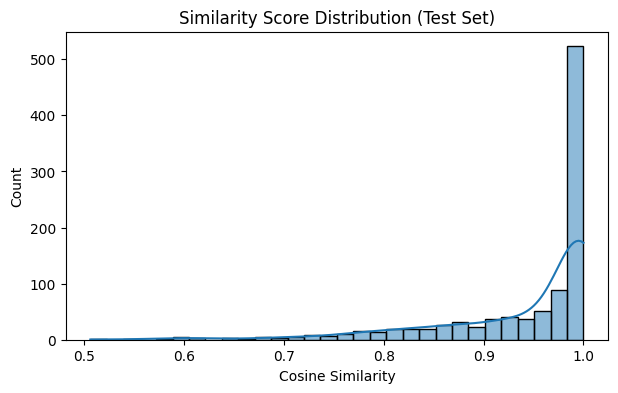

In [14]:
scores = []

for row in test_df.sample(1000, random_state=42).itertuples():
    _, _, score = retrieve_answer(row.questions)
    scores.append(score)

plt.figure(figsize=(7,4))
sns.histplot(scores, bins=30, kde=True)
plt.title("Similarity Score Distribution (Test Set)")
plt.xlabel("Cosine Similarity")
plt.show()

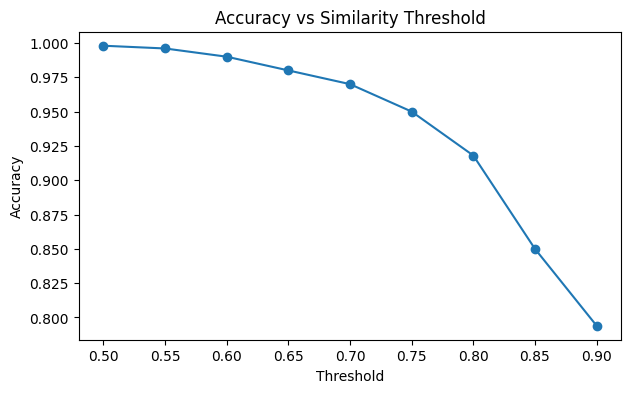

In [15]:
thresholds = np.linspace(0.5, 0.9, 9)
accs = [evaluate_accuracy(test_df.sample(500), t) for t in thresholds]

plt.figure(figsize=(7,4))
plt.plot(thresholds, accs, marker="o")
plt.title("Accuracy vs Similarity Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()